# Analysis of Degree Modifiers in Wiki talk-pages
## Outline:
- Start with some list of modifiers of degree
- open wiki talk pages and see if there are other hedges by asking gemini
- create final list of modifiers of degree by adding the found set
- extract all modifiers of degree based on string matching
- use gemini to filter out cases where modifiers of degree appear 
- add labels of the context in which the modifier is used including the following:
    - whether it's in a question
    - valence 
    - whether the modifier fuctions to soften the utterance, be formal, or be literal


Load libraries etc

In [ ]:
from prompt_explanation_store import EN_MODIFIER_EXPLANATIONS, JP_MODIFIER_EXPLANATIONS,check_modifier_prompt, jp_valence_prompt, en_valence_prompt

{'a little': 'Explanation: The phrase "a little" can function both as a modifier of degree ("slightly"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:\n- Example: She was a little tired after the trip. (= slightly)\n- Non-example: He lives in a little house by the lake. (= small; "little" here is a literal size adjective modifying "house," not scaling the degree of another word)\n- Non-example: He only ate a little before leaving. (= a small amount; functions as a noun phrase/quantity pronoun, not modifying an adjective or verb)', 'a bit': 'Explanation: The phrase "a bit" can function both as a modifier of degree ("slightly"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:\n- Example: This is a bit expensive. (= slightly)\n- Non-example: Can I have a bit of that cake? (= a small piece/amount; functions as a quantity noun phrase, not modifying an adjective directly)

In [2]:
import os
from google import genai
from dotenv import load_dotenv
import json
import pandas as pd
import xml.etree.ElementTree as ET
from google.genai import types
load_dotenv()
client = genai.Client(
    api_key=os.getenv("google_api_key"),
)

MAX_ENTRIES = 1000

Functions

In [3]:
import json, re

def parse_model_json(response):
    """Robust parser: strips backtick fences and quotes bare keys before parsing."""
    text = response.strip()
    text = re.sub(r'^`+\s*(?:json)?\s*', '', text)
    text = re.sub(r'\s*`+\s*$', '', text)
    text = text.strip()
    text = re.sub(r'([{,]\s*)([A-Za-z_][A-Za-z0-9_]*)\s*:', r'\1"\2":', text)
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return None


def extract_key_value(response_text, key):
    """Extract a single field (e.g. "category") from the model's JSON response text."""
    parsed = parse_model_json(response_text)
    if parsed is None:
        return None
    return parsed.get(key)


def get_index_output(row, key):
    """
    Given one line from a downloaded batch result JSONL file, return
    (index, value): index is the original DataFrame row index (from the
    request's "key" field), value is the requested field extracted from
    the model's JSON response.
    """
    result = json.loads(row) if isinstance(row, str) else row

    request_key = result.get("key")
    index = int(request_key) if request_key is not None else None

    if not result.get("response"):
        print(f"Error for key {request_key}: {result.get('error')}")
        return index, None

    try:
        response_text = result["response"]["candidates"][0]["content"]["parts"][0]["text"]
    except (KeyError, IndexError):
        return index, None

    return index, extract_key_value(response_text, key)
def create_inline_requests(replacement_tuples, prompt_text,key):
    for replace_tuple in replacement_tuples:
        prompt_text = prompt_text.replace(replace_tuple[0], replace_tuple[1])
    return { "key": key, "request": {"contents": [{"parts": [{"text": prompt_text}], "role": "user"}]},}

def create_batch_job(inline_requests, display_name, model="gemini-3-flash-preview"):
    batch_input_path = f"{display_name}_input.jsonl"
    with open(batch_input_path, "w", encoding="utf-8") as f:
        for req in inline_requests:
            f.write(json.dumps(req, ensure_ascii=False) + "\n")

    uploaded_file = client.files.upload(
        file=batch_input_path,
        config=types.UploadFileConfig(display_name=display_name, mime_type="jsonl"),
    )

    batch_job = client.batches.create(
        model=model,
        src=uploaded_file.name,
        config={'display_name': display_name},
    )
    return batch_job

### Decide on list of hedges

Prompt wordings

Hedge example uses

In [194]:
# check the first 1000 pages to see that we are not missing any modifiers of degree which occur relatively frequently.
namespace = {}
count = 0
# set directory to one above where this code is
# set to current directory where this file is
# create jsonl in one above current directory in /data
# set current directory to where this notebook is
inline_requests = []
os.chdir('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/jawiki_data')
for file_string in os.listdir():
    for event, elem in ET.iterparse(file_string, events=['start','end']): #events=['end'] means levaves parsed before parent
        tag = elem.tag.split('}')[-1] if '}' in elem.tag else elem.tag
    # # create progress bar for count
    # pbar = tqdm(total=100)
        if tag == 'namespaces':
            for child in elem:
                child_tag = child.tag.split('}')[-1] if '}' in child.tag else child.tag
                namespace[child.attrib['key']] = child.text
        if event == 'end' and tag == 'page': # {website link}fins would not work. it has to be {namespace}ns
            if elem.find('{*}ns').text == '3': # this should be all user talk pages
                # print all children of elem
                for child in elem:
                    content = child.tag.split('}')[-1] if '}' in child.tag else child.tag
                    if content == 'revision':
                        timestamp = child.find('{*}timestamp').text if child.find('{*}timestamp') is not None else None
                        # print("timestamp:", timestamp)
                        comment = child.find('{*}comment').text if child.find('{*}comment') is not None else None
                        # print("comment:", comment)
                        text = child.find('{*}text').text if child.find('{*}text') is not None else None
                        # print("text:", text)
                        # break text up by newlines and parse each line for hedging language
                        if text is not None:
                            # split for newline
                            inline_requests.append(create_inline_requests([("{text}", text)], jp_find_other_modifier_prompt, count))
                            count += 1
                            break
            elem.clear()

724501


In [205]:
with open('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/jp_check_hedge_comprehensiveness.jsonl', 'w') as f:
    for request in inline_requests:
        f.write(json.dumps(request, ensure_ascii=False) + '\n')
create_batch_job(inline_requests[::10] , "jp_find_other_modifiers")

In [ ]:
# only take lines of file which are 0 mod 10
with open('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/en_check_hedge_comprehensiveness.jsonl', 'r') as f:
    lines = f.readlines()
    selected_lines = [line for i, line in enumerate(lines) if i % 10 == 0]
# save smaller file
with open('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/en_check_hedge_comprehensiveness_small.jsonl', 'w') as f:
    f.writelines(selected_lines)    

In [212]:
output_path = "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_find_other_modifiers_output.jsonl"

with open(output_path, "w", encoding="utf-8") as f:
    for batch in client.batches.list():
        if batch.display_name == "jp_find_other_modifiers":
            file_content = client.files.download(file=batch.dest.file_name).decode("utf-8")
            f.write(file_content)
            if not file_content.endswith("\n"):
                f.write("\n")


In [104]:
from collections import Counter
modifier_counter = Counter()
with open(output_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        try:
            line_json = parse_model_json(json.loads(line)['response']['candidates'][0]['content']['parts'][0]['text'])
            if len(line_json) > 0:
                for entry in line_json:
                    modifier_counter[entry['modifier']] += 1
        except:
            # print(json.loads(line))
            continue
        
for modifier, count in modifier_counter.most_common():
    print(f"{modifier}: {count}")  

NameError: name 'output_path' is not defined

## Extract strings from talk pages

In [7]:
def split_sentences(text):
    # Split on delimiters NOT inside 「」 or ""
    # Use negative lookbehind to avoid splitting inside quotes
    sentences = []
    current = ""
    quote_stack = []
    en_quote_odd = False
    
    for i, char in enumerate(text):
        current += char
        if char in '"':
            en_quote_odd = not en_quote_odd
        if char in '「[':
            quote_stack.append(char)
        elif char in '」]':
            if quote_stack:
                quote_stack.pop()
        elif char in '。？?!！.\n' and not quote_stack and not en_quote_odd:
            sentences.append(current)
            current = ""
        if char in '「[':
            quote_stack.append(char)
        elif char in '」]':
            if quote_stack:
                quote_stack.pop()
        elif char in '。？?!！.\n' and not quote_stack:
            sentences.append(current)
            current = ""
    
    if current.strip():
        sentences.append(current)
    
    return sentences
def find_rough_hedged_count(line,language):
    """Find hedging language followed by adjectives."""
    # Check single-word hedges
    results = []    
    if language == "en":
        for modifier in EN_ALL_MODIFIER_WORDS:
            if re.search(modifier[0], line, re.IGNORECASE):
                results.append({
                    'modifier': modifier[1],  # Use lowercase for consistency
                    'sentence': line
                })
    elif language == "jp":
        for modifier in JP_ALL_MODIFIER_WORDS:
            if modifier in line:
                results.append({
                    'modifier': modifier,  # Use lowercase for consistency
                    'sentence': line
                })  
    return results

In [ ]:
modified_sentences = []
count=0
page_count=0
os.chdir('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/jawiki_data')
for file_string in os.listdir():
    for event, elem in ET.iterparse(file_string, events=['start','end']): #events=['end'] means levaves parsed before parent
        tag = elem.tag.split('}')[-1] if '}' in elem.tag else elem.tag
        # # create progress bar for count
        # pbar = tqdm(total=100)
        if event == 'end' and tag == 'page': # {website link}fins would not work. it has to be {namespace}ns
            if elem.find('{*}ns').text == '3': # this should be all user talk pages
                # print all children of elem
                for child in elem:
                    content = child.tag.split('}')[-1] if '}' in child.tag else child.tag
                    if content == 'revision':
                        timestamp = child.find('{*}timestamp').text if child.find('{*}timestamp') is not None else None
                        # print("timestamp:", timestamp)
                        comment = child.find('{*}comment').text if child.find('{*}comment') is not None else None
                        # print("comment:", comment)
                        text = child.find('{*}text').text if child.find('{*}text') is not None else None
                        # print("text:", text)
                        # break text up by newlines and parse each line for hedging language
                        if text is not None:
                            # split if 。or ？ or newline but also include it
                            # join odd and even indices to get sentences with punctuation
                            for subtext in text.split('\n'):
                                for line in split_sentences(subtext):
                                    modified_sentences.extend(find_rough_hedged_count(line,"jp"))

                count += 1
            elem.clear()
            page_count += 1
            if page_count % 10000 == 0:
                print(f"Processed {page_count} pages and {count} sentences...")
df = pd.DataFrame(modified_sentences)
# ignore duplicate rows
df.drop_duplicates(inplace=True)
df.to_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/jp_hedges_unfiltered.csv', index=False, encoding='utf-8-sig')

## omit all frequently occuring template messages:
adequately (Template:Uw-delete1), poorly ([[Wikipedia:Citing sources|unsourced or poorly sourced]] ), substantially ("substantially expanded"),("However, as a .... are strictly for discussing...."), less than "your recent posts....", "sufficiently" (not sufficiently notable) and in full are both templates messages
これ以上：”あなたがこれ以上、[[:内陸県]]でなさったような投稿を続けると、ウィキペディアの編集ができなくなる[[Wikipedia:投稿ブロックの方針|投稿ブロック]]の対象となります。”

In [ ]:
# count freq of each modifier
# add combined_modifier column based on JP_MODIFIER_GROUPS
# df['combined_modifier'] = df['modifier'].apply(lambda x: JP_MODIFIER_GROUPS[x] if x in JP_MODIFIER_GROUPS else x)
# df.to_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedges_unfiltered.csv', index=False, encoding='utf-8-sig')
# df.drop_duplicates(inplace=True)
# df.to_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedges_unfiltered.csv', index=False, encoding='utf-8-sig')
for modifier in df['combined_modifier'].value_counts().index:
    print(f"Modifier: {modifier}, Count: {len(df[df['combined_modifier'] == modifier])}")
# modifier_counts = df['modifier'].value_counts()
# see if there are ones with 0 count
modifier_counts = df['combined_modifier'].value_counts()


## Gemini judges whether the strings extracted as 'hedges' are indeed used as degree modifiers

In [100]:
en_string_extracted = pd.read_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedges_unfiltered.csv')
# en_string_extracted = pd.read_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedges_unfiltered.csv')

# 1. 1行ごとにインラインリクエストを作る（DataFrameの順序のまま）
inline_requests = []
for index, row in en_string_extracted.iterrows():
    try:    
        modifier = row['modifier']
        sentence = row['sentence']
        prompt_text = EN_MODIFIER_EXPLANATIONS[modifier] + check_modifier_prompt
        inline_requests.append(create_inline_requests([("{modifier}", modifier), ("{sentence}", sentence)], prompt_text,key=index))
    except KeyError as e:
        # print(f"KeyError: {e} for index {index}")
        # print(f"Row data: {row}")
        continue
    if index>50000:  # limit to first 10000 rows for testing
        break
# print(inline_requests[6]['request']['contents'][0]['parts'][0]['text'])  # print first 2 inline requests for verification
create_batch_job(inline_requests, "en_check_modifier_explanation")


BatchJob(
  create_time=datetime.datetime(2026, 7, 12, 19, 44, 47, 100875, tzinfo=TzInfo(UTC)),
  display_name='en_check_modifier_explanation',
  model='models/gemini-3-flash-preview',
  name='batches/6ppnxe6fdlttiqrf515os6pfa0b3bcm4l4zl',
  state=<JobState.JOB_STATE_PENDING: 'JOB_STATE_PENDING'>,
  update_time=datetime.datetime(2026, 7, 12, 19, 44, 47, 100875, tzinfo=TzInfo(UTC))
)

In [ ]:

jp_string_extracted = pd.read_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedges_unfiltered.csv')
all_lines=[]
for job in client.batches.list():   
    print(f"Status: {job.state}, {job.display_name}")
    ## uncoment below once job has succeeded
    if job.display_name == "jp_check_modifier_explanation":
        file_content = client.files.download(file=job.dest.file_name).decode("utf-8")
        all_lines.extend(file_content.splitlines())
jp_string_extracted["is_modifier"] = None
for row in all_lines:
    index, relevant_output = get_index_output(row, key="is_modifier")
    jp_string_extracted.at[index, "is_modifier"] = relevant_output
# # only keep rows where is_modifier is True and change all entries which are true, "true" etc to True
jp_string_extracted["is_modifier"] = jp_string_extracted["is_modifier"].replace({"true": True, "True": True})
# # 3. 元の全列 + is_modifier列で新しいファイルとして保存
jp_string_extracted[jp_string_extracted["is_modifier"]==True].to_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentences_modifier_checkedJul12.csv", index=False, encoding="utf-8-sig"
)


Status: JOB_STATE_SUCCEEDED, en_use_category
Status: JOB_STATE_SUCCEEDED, jp_use_category
Status: JOB_STATE_SUCCEEDED, en_check_modifier_explanation
Status: JOB_STATE_SUCCEEDED, jp_check_modifier_explanation


In [116]:
jp_modifier_checked = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentences_modifier_checkedJul12.csv")
en_modifier_checked = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedged_sentences_modifier_checkedJul12.csv")
file_start = ["jp", "en"]
files = {"jp": jp_modifier_checked, "en": en_modifier_checked}
explanations = [jp_valence_prompt, en_valence_prompt]

for i, file in enumerate([jp_modifier_checked, en_modifier_checked]):
    inline_requests = []
    for index, row in file.iterrows():
        modifier = row.modifier
        sentence = row.sentence
        inline_requests.append(create_inline_requests([("{modifier}", modifier), ("{sentence}", sentence)], explanations[i], key=index))
    create_batch_job(inline_requests, f"{file_start[i]}_use_category")

In [5]:
# list currently running jobs
jp_modifier_checked = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentences_modifier_checkedJul12.csv")
all_lines=[]
for job in client.batches.list():   
    print(f"Status: {job.state}, {job.display_name}")
    if job.display_name == "jp_use_category":
        file_content = client.files.download(file=job.dest.file_name).decode("utf-8")
        all_lines.extend(file_content.splitlines())
jp_modifier_checked["category"] = None
for row in all_lines:
    index, relevant_output = get_index_output(row, key="category")
    jp_modifier_checked.at[index, "category"] = relevant_output
# # 3. 元の全列 + category列で新しいファイルとして保存
jp_modifier_checked.to_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentences_category_checkedJul12.csv", index=False, encoding="utf-8-sig")

Status: JOB_STATE_SUCCEEDED, en_use_category
Status: JOB_STATE_SUCCEEDED, jp_use_category
Status: JOB_STATE_SUCCEEDED, en_check_modifier_explanation
Status: JOB_STATE_SUCCEEDED, jp_check_modifier_explanation
Error for key 30042: {'code': 13, 'message': 'Internal error encountered.'}
Error for key 30064: {'code': 13, 'message': 'Internal error encountered.'}
Error for key 1427: {'code': 13, 'message': 'Internal error encountered.'}
Error for key 7511: {'code': 13, 'message': 'Internal error encountered.'}
Error for key 4781: {'code': 13, 'message': 'Internal error encountered.'}
Error for key 21629: {'code': 13, 'message': 'Internal error encountered.'}
Error for key 9239: {'code': 13, 'message': 'Internal error encountered.'}
Error for key 10252: {'code': 13, 'message': 'Internal error encountered.'}
Error for key 23607: {'code': 13, 'message': 'Internal error encountered.'}
Error for key 23701: {'code': 13, 'message': 'Internal error encountered.'}
Error for key 22125: {'code': 13, 'm

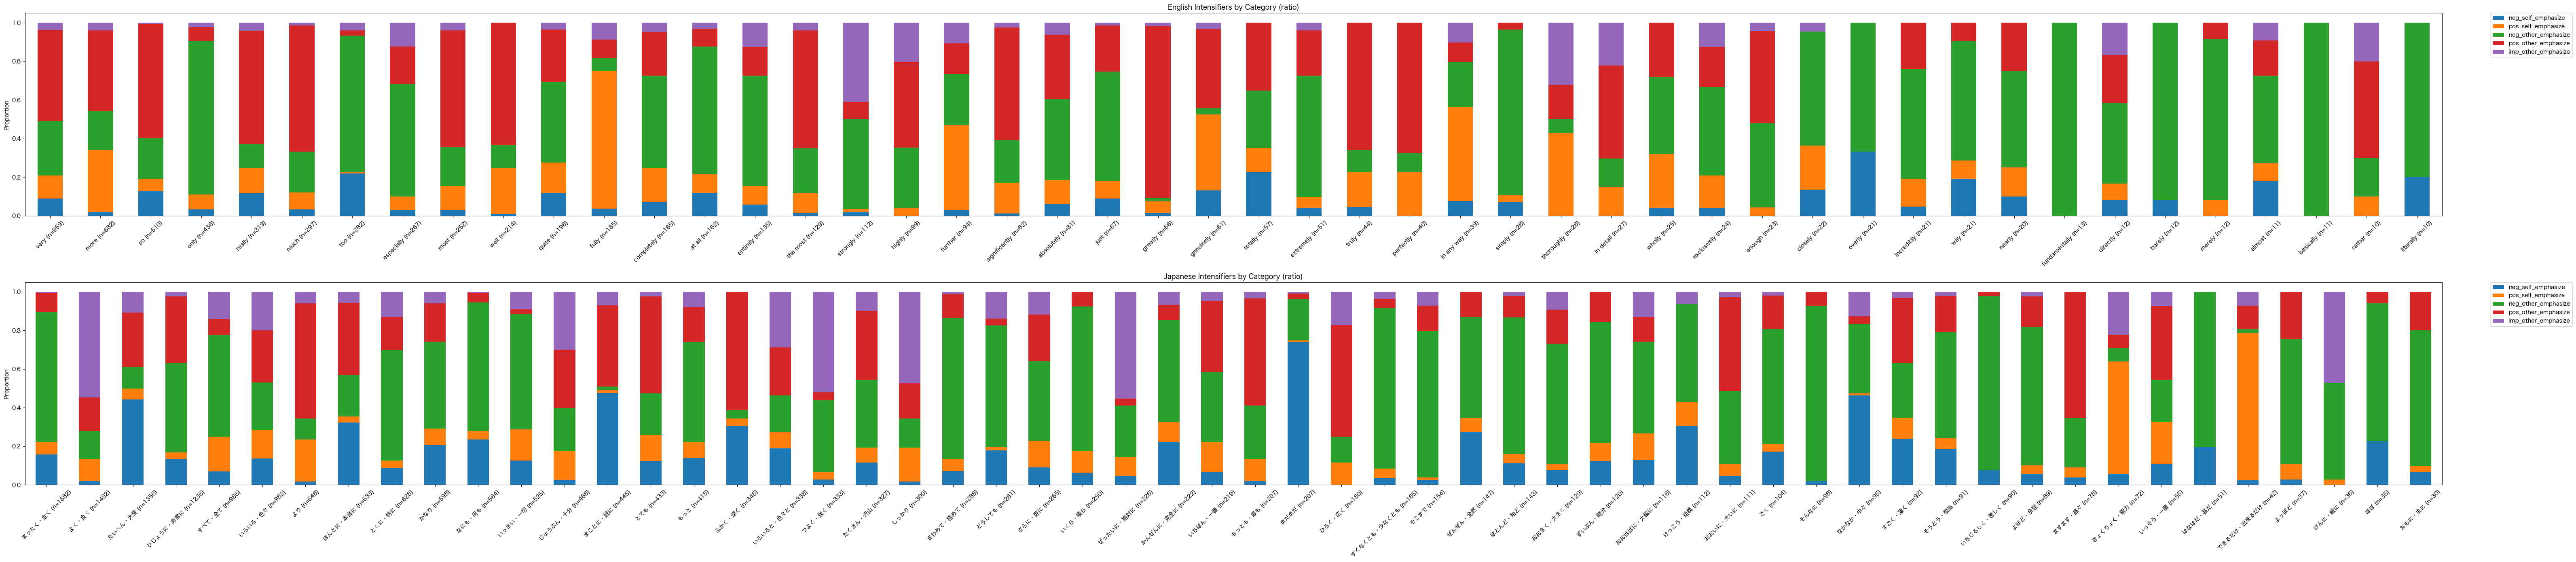

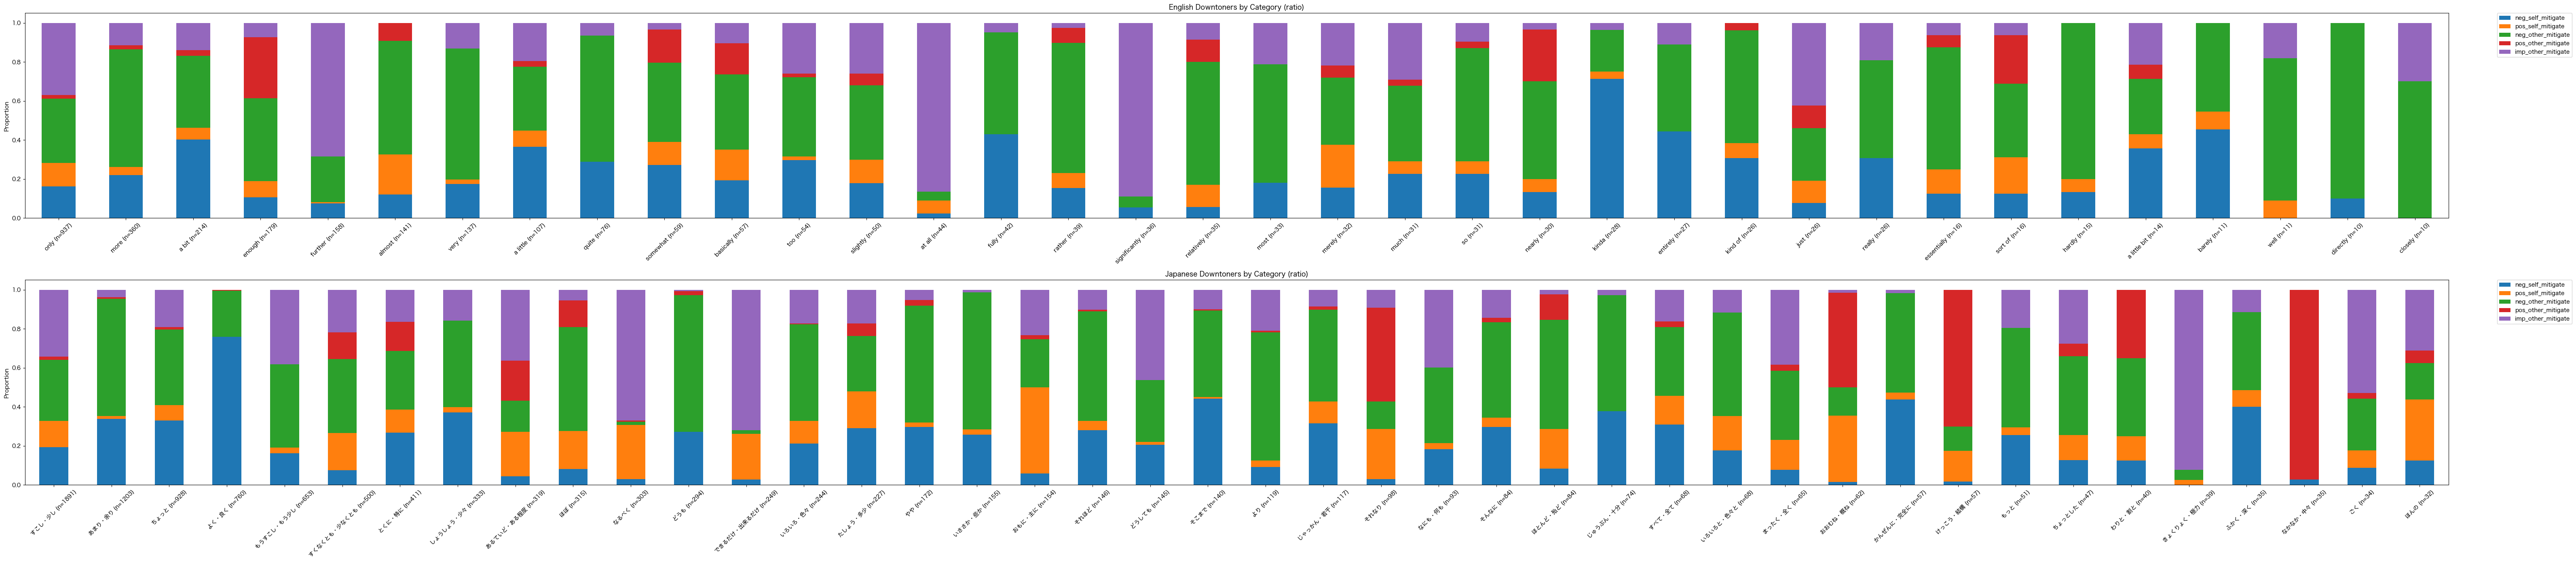

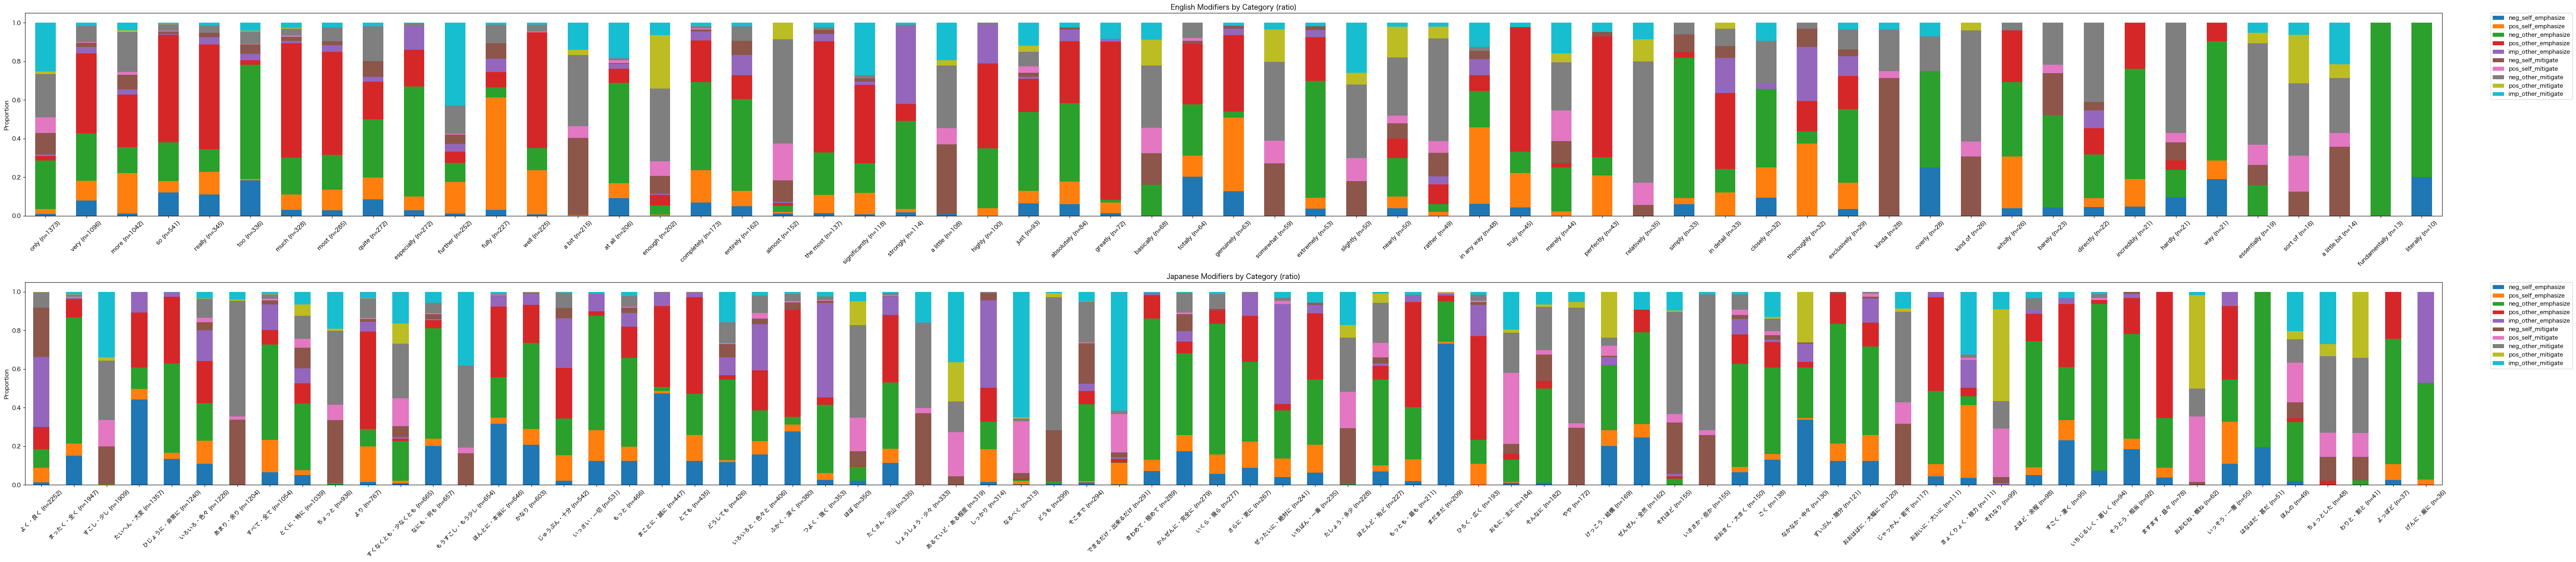

In [43]:
import matplotlib.pyplot as plt
en_modifier_checked = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedged_sentences_category_checkedJul12.csv")
jp_modifier_checked = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentences_category_checkedJul12.csv")
plt.rcParams['font.family'] = 'Hiragino Sans'
jp_modifier_checked = jp_modifier_checked[jp_modifier_checked['modifier']!="これ以上"]
en_modifier_checked = en_modifier_checked[~en_modifier_checked['modifier'].isin(["in full","poorly","adequately","substantially","strictly","less than","sufficiently"])] # adequately (Template:Uw-delete1), poorly ([[Wikipedia:Citing sources|unsourced or poorly sourced]] ), substantially ("substantially expanded"),("However, as a .... are strictly for discussing...."), less than "your recent posts....", "sufficiently" (not sufficiently notable) and in full are both templates messages
# only: many automated messages -  If you only....
intensifier_cats = ['neg_self_emphasize', 'pos_self_emphasize', 'neg_other_emphasize',
                     'pos_other_emphasize', 'imp_other_emphasize']
downtoner_cats = ['neg_self_mitigate', 'pos_self_mitigate', 'neg_other_mitigate',
                   'pos_other_mitigate', 'imp_other_mitigate']

MIN_N_JP = 30
MIN_N_EN = 10 

def plot_group(df, cats, title, ax,MIN_N=20):
    subset = df[df['category'].isin(cats)]
    group_col = 'combined_modifier' if 'combined_modifier' in subset.columns else 'modifier'

    counts = subset.groupby([group_col, 'category']).size().unstack(fill_value=0)
    counts = counts.reindex(columns=cats, fill_value=0)

    totals = counts.sum(axis=1)
    # only keep ones above MIN_N
    counts = counts[totals >= MIN_N]
    totals = totals[totals >= MIN_N]

    # order by count, descending, so more common words are on one side
    order = totals.sort_values(ascending=False).index
    counts = counts.loc[order]
    totals = totals.loc[order]

    ratio = counts.div(totals, axis=0)
    ratio.index = [f"{word} (n={totals[word]})" for word in ratio.index]
    ratio.plot(kind='bar', stacked=True, ax=ax, title=title)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    ax.set_ylabel('Proportion')

n_words = max(en_modifier_checked['modifier'].nunique(), jp_modifier_checked['combined_modifier'].nunique())

# --- intensifiers ---
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(max(14, n_words * 0.6), 14))
plot_group(en_modifier_checked, intensifier_cats, 'English Intensifiers by Category (ratio)', axes[0],MIN_N=MIN_N_EN)
plot_group(jp_modifier_checked, intensifier_cats, 'Japanese Intensifiers by Category (ratio)', axes[1],MIN_N=MIN_N_JP)
plt.tight_layout()
plt.show()

# --- downtoners ---
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(max(14, n_words * 0.6), 14))
plot_group(en_modifier_checked, downtoner_cats, 'English Downtoners by Category (ratio)', axes[0],MIN_N=MIN_N_EN)
plot_group(jp_modifier_checked, downtoner_cats, 'Japanese Downtoners by Category (ratio)', axes[1],MIN_N=MIN_N_JP)
plt.tight_layout()
plt.show()

# --- all ---
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(max(14, n_words * 0.6), 14))
plot_group(en_modifier_checked, intensifier_cats + downtoner_cats, 'English Modifiers by Category (ratio)', axes[0],MIN_N=MIN_N_EN)
plot_group(jp_modifier_checked, intensifier_cats + downtoner_cats, 'Japanese Modifiers by Category (ratio)', axes[1],MIN_N=MIN_N_JP)
plt.tight_layout()
plt.show()

### Different ways of comparing variation in modifiers

In [44]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from itertools import combinations
# jp_modifier_checked = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentences_category_checked.csv")
# en_modifier_checked = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedged_sentences_category_checked.csv")
# only keep hedges in [very, really, extremely, quite a bit]
# en_modifier_checked = en_modifier_checked[en_modifier_checked['hedge'].isin(['very', 'really', 'extremely', 'quite a bit','mostly','largely','reasonably','moderately','somewhat','fairly'])]
# only keep modifeirs in a little, rather, a bit, quite, slightly, pretty, mostly, relatively, partially, somewhat, largely, fairly, moderately, kind of, sort of, reasonably
# en_modifier_checked = en_modifier_checked[en_modifier_checked['hedge'].isin(['a little', 'rather', 'a bit', 'quite', 'slightly', 'pretty', 'relatively', 'partially', 'somewhat', 'largely', 'fairly', 'moderately', 'kind of', 'sort of', 'reasonably'])]
# keep only the most frequent 5
en_modifier_counts = en_modifier_checked.groupby(['modifier', 'category']).size().unstack(fill_value=0)
# only keep modifiers in 大変, かなり, 相当, 非常に, 十分, とても, ずいぶん, すごく, やたら, とっても
# jp_modifier_checked = jp_modifier_checked[jp_modifier_checked['hedge'].isin(['大変', 'かなり', '相当', '非常に', '十分', 'とても', 'ずいぶん', 'すごく', 'やたら', 'とっても'])]
# only keep modifiers in 少し, あまり, ちょっと, 多少, それなり, 結構, ある程度, やや, いささか, 若干, わりと, ちょっぴり
# jp_modifier_checked = jp_modifier_checked[jp_modifier_checked['hedge'].isin(['少し', 'あまり', 'ちょっと', '多少', 'それなり', '結構', 'ある程度', 'やや', 'いささか', '若干', 'わりと', 'ちょっぴり'])]
jp_modifier_counts = jp_modifier_checked.groupby(['combined_modifier', 'category']).size().unstack(fill_value=0)

# get rid of rows with cateogory neutral or other, since they are not informative for the comparison
en_modifier_counts = en_modifier_counts.drop(columns=['neutral', 'unclear'], errors='ignore')
jp_modifier_counts = jp_modifier_counts.drop(columns=['neutral', 'unclear'], errors='ignore')
# en_modifier_checked = en_modifier_checked[en_modifier_checked['hedge'].isin(en_modifier_checked['hedge'].value_counts().nlargest(10).index)]
# jp_modifier_checked = jp_modifier_checked[jp_modifier_checked['hedge'].isin(jp_modifier_checked['hedge'].value_counts().nlargest(10).index)]

en_modifier_ratio = en_modifier_counts.div(en_modifier_counts.sum(axis=1), axis=0)
jp_modifier_ratio = jp_modifier_counts.div(jp_modifier_counts.sum(axis=1), axis=0)

MIN_N = 30

def pairwise_jsd_weighted(ratio_df, count_df):
    totals = count_df.sum(axis=1)
    words = ratio_df.index.tolist()
    results = []
    for w1, w2 in combinations(words, 2):
        p, q = ratio_df.loc[w1].values, ratio_df.loc[w2].values
        print(p,q)
        jsd = jensenshannon(p, q, base=2)
        weight = totals[w1] * totals[w2]  # conservative: limited by the rarer word
        results.append((w1, w2, jsd, weight))
    return pd.DataFrame(results, columns=['word1', 'word2', 'jsd', 'weight'])

# filter to words with enough data before computing pairs
en_keep = en_modifier_counts[en_modifier_counts.sum(axis=1) >= MIN_N_EN]
jp_keep = jp_modifier_counts[jp_modifier_counts.sum(axis=1) >= MIN_N_JP]
en_ratio_keep = en_modifier_ratio.loc[en_keep.index]
jp_ratio_keep = jp_modifier_ratio.loc[jp_keep.index]

en_jsd = pairwise_jsd_weighted(en_ratio_keep, en_keep)
jp_jsd = pairwise_jsd_weighted(jp_ratio_keep, jp_keep)

en_weighted_mean = np.average(en_jsd['jsd'], weights=en_jsd['weight'])
jp_weighted_mean = np.average(jp_jsd['jsd'], weights=jp_jsd['weight'])
print("English weighted mean JSD:", en_weighted_mean)
print("Japanese weighted mean JSD:", jp_weighted_mean)


def bootstrap_weighted_mean_diff(jsd1, jsd2, n_iter=10000):
    p1 = jsd1['weight'].values / jsd1['weight'].sum()
    p2 = jsd2['weight'].values / jsd2['weight'].sum()
    diffs = np.empty(n_iter)
    for i in range(n_iter):
        s1 = np.random.choice(jsd1['jsd'].values, size=len(jsd1), replace=True, p=p1)
        s2 = np.random.choice(jsd2['jsd'].values, size=len(jsd2), replace=True, p=p2)
        diffs[i] = s1.mean() - s2.mean()
    ci = np.percentile(diffs, [2.5, 97.5])
    return diffs.mean(), ci

mean_diff, ci = bootstrap_weighted_mean_diff(en_jsd, jp_jsd)
print(f"EN - JP weighted mean JSD diff: {mean_diff:.4f}, 95% CI: {ci}")

[0.         0.13953488 0.         0.36744186 0.         0.4
 0.         0.02790698 0.00465116 0.06046512 0.        ] [0.         0.19266055 0.         0.32110092 0.00917431 0.35779817
 0.         0.02752294 0.         0.08256881 0.00917431]
[0.         0.13953488 0.         0.36744186 0.         0.4
 0.         0.02790698 0.00465116 0.06046512 0.        ] [0.         0.21428571 0.         0.28571429 0.         0.35714286
 0.         0.07142857 0.         0.07142857 0.        ]
[0.         0.13953488 0.         0.36744186 0.         0.4
 0.         0.02790698 0.00465116 0.06046512 0.        ] [0.05952381 0.02380952 0.4047619  0.         0.05952381 0.01190476
 0.32142857 0.         0.11904762 0.         0.        ]
[0.         0.13953488 0.         0.36744186 0.         0.4
 0.         0.02790698 0.00465116 0.06046512 0.        ] [0.00657895 0.         0.03289474 0.53947368 0.01315789 0.11184211
 0.01315789 0.08552632 0.00657895 0.19078947 0.        ]
[0.         0.13953488 0.         0.

In [48]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy, wasserstein_distance
from itertools import combinations

EPS = 1e-10  # smoothing to avoid divide-by-zero / log(0) in KL and chi-squared

def pairwise_distances_weighted(ratio_df, count_df):
    totals = count_df.sum(axis=1)
    words = ratio_df.index.tolist()
    results = []
    for w1, w2 in combinations(words, 2):
        p = ratio_df.loc[w1].values.astype(float)
        q = ratio_df.loc[w2].values.astype(float)
        p_smooth = p + EPS
        q_smooth = q + EPS
        p_smooth /= p_smooth.sum()
        q_smooth /= q_smooth.sum()

        jsd = jensenshannon(p, q, base=2)
        kl_pq = entropy(p_smooth, q_smooth, base=2)          # KL(p || q)
        kl_qp = entropy(q_smooth, p_smooth, base=2)          # KL(q || p), since KL is asymmetric
        tvd = 0.5 * np.abs(p - q).sum()                      # total variation distance
        hellinger = np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))
        chi_sq = np.sum((p_smooth - q_smooth) ** 2 / (p_smooth + q_smooth))
        wasserstein = wasserstein_distance(range(len(p)), range(len(q)), p, q)  # treats category order as-is
        cosine_dist = 1 - np.dot(p, q) / (np.linalg.norm(p) * np.linalg.norm(q) + EPS)

        weight = totals[w1] * totals[w2]

        results.append((w1, w2, jsd, kl_pq, kl_qp, tvd, hellinger, chi_sq, wasserstein, cosine_dist, weight))

    return pd.DataFrame(results, columns=[
        'word1', 'word2', 'jsd', 'kl_pq', 'kl_qp', 'tvd', 'hellinger',
        'chi_sq', 'wasserstein', 'cosine_dist', 'weight'
    ])

# filter to words with enough data before computing pairs
en_keep = en_modifier_counts[en_modifier_counts.sum(axis=1) >= MIN_N_EN]
jp_keep = jp_modifier_counts[jp_modifier_counts.sum(axis=1) >= MIN_N_JP]
en_ratio_keep = en_modifier_ratio.loc[en_keep.index]
jp_ratio_keep = jp_modifier_ratio.loc[jp_keep.index]

en_dist = pairwise_distances_weighted(en_ratio_keep, en_keep)
jp_dist = pairwise_distances_weighted(jp_ratio_keep, jp_keep)

metrics = ['jsd', 'kl_pq', 'kl_qp', 'tvd', 'hellinger', 'chi_sq', 'wasserstein', 'cosine_dist']

for m in metrics:
    en_wm = np.average(en_dist[m], weights=en_dist['weight'])
    jp_wm = np.average(jp_dist[m], weights=jp_dist['weight'])
    print(f"{m:12s}  EN={en_wm:.4f}  JP={jp_wm:.4f}")


def bootstrap_weighted_mean_diff(df1, df2, metric, n_iter=10000):
    p1 = df1['weight'].values / df1['weight'].sum()
    p2 = df2['weight'].values / df2['weight'].sum()
    diffs = np.empty(n_iter)
    for i in range(n_iter):
        s1 = np.random.choice(df1[metric].values, size=len(df1), replace=True, p=p1)
        s2 = np.random.choice(df2[metric].values, size=len(df2), replace=True, p=p2)
        diffs[i] = s1.mean() - s2.mean()
    ci = np.percentile(diffs, [2.5, 97.5])
    return diffs.mean(), ci


for m in metrics:
    mean_diff, ci = bootstrap_weighted_mean_diff(en_dist, jp_dist, m)
    sig = "significant" if ci[0] > 0 or ci[1] < 0 else "not significant"
    print(f"{m:12s}  EN-JP diff={mean_diff:.4f}  95% CI=[{ci[0]:.4f}, {ci[1]:.4f}]  ({sig})")

jsd           EN=0.5364  JP=0.6357
kl_pq         EN=3.2678  JP=5.7056
kl_qp         EN=4.4407  JP=6.8216
tvd           EN=0.5220  JP=0.6248
hellinger     EN=0.4830  JP=0.5858
chi_sq        EN=0.7450  JP=1.0031
wasserstein   EN=1.3797  JP=1.2872
cosine_dist   EN=0.4415  JP=0.5532
jsd           EN-JP diff=-0.0994  95% CI=[-0.1120, -0.0867]  (significant)
kl_pq         EN-JP diff=-2.4356  95% CI=[-2.7944, -2.0754]  (significant)
kl_qp         EN-JP diff=-2.3792  95% CI=[-2.8213, -1.9437]  (significant)
tvd           EN-JP diff=-0.1029  95% CI=[-0.1167, -0.0893]  (significant)
hellinger     EN-JP diff=-0.1028  95% CI=[-0.1153, -0.0905]  (significant)
chi_sq        EN-JP diff=-0.2582  95% CI=[-0.2887, -0.2276]  (significant)
wasserstein   EN-JP diff=0.0922  95% CI=[0.0541, 0.1309]  (significant)
cosine_dist   EN-JP diff=-0.1118  95% CI=[-0.1291, -0.0939]  (significant)


### save to file

## Add judgements of dimensions of context
### Valence

### Check the following for each:
- (0) check if it is used as a modifier
- (1) if it is a question 
- (2) need for softening 
- (3) formality 
- (4) bearing on degree 
- (5) valence


In [ ]:

en_string_extracted = pd.read_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedged_gemini_labeled_sentences_checked.csv')
inline_requests = []
for row in en_string_extracted.itertuples():
    if en_string_extracted["is_modifier"][row.Index] == True:
        hedge = row.hedge
        sentence = row.sentence
        inline_requests.append(create_inline_requests([("{modifier}", hedge), ("{sentence}", sentence)], en_valence_prompt))

create_batch_job(inline_requests, display_name="en-hedge-category-classification")
# print(len(inline_requests))
    

BatchJob(
  create_time=datetime.datetime(2026, 7, 11, 21, 10, 42, 975459, tzinfo=TzInfo(UTC)),
  display_name='en-hedge-valence-classification',
  model='models/gemini-3-flash-preview',
  name='batches/ztzlyefx6p5xxqe3ft4a081af4upb79yrrnm',
  state=<JobState.JOB_STATE_PENDING: 'JOB_STATE_PENDING'>,
  update_time=datetime.datetime(2026, 7, 11, 21, 10, 42, 975459, tzinfo=TzInfo(UTC))
)

In [58]:
# open july9 csv
jp_string_extracted = pd.read_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentencesJuly9_modifier_checked.csv')
jp_string_extracted["category"] = None
for index, row in jp_string_extracted.iterrows():
    print(index,row)
    break

0 hedge                                                         やや
sentence       僕が（投稿者本人以外が）移動をすると、要約欄への書き込みなどいろいろややこしい部分があるので...
is_modifier                                                False
modifies                                                     NaN
category                                                    None
Name: 0, dtype: object


In [ ]:
jp_string_extracted["category"] = None
batch = client.batches.get(name=batch_job.name)  # 完了後に取得し直す
file_content = client.files.download(file=batch.dest.file_name).decode("utf-8")
output_file = file_content.splitlines()
for row in output_file:
    index, relevant_output = get_index_output(row, key="category")
    jp_string_extracted.at[index, "category"] = relevant_output

NameError: name 'MODIFIER_CHECK_EXPLANATIONS' is not defined

## Generate frequency plots for each dimension

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DEFAULT_DIMENSIONS = ["softener", "formality", "degree", "valence"]


def plot_average_by_modifier(
    results_df: pd.DataFrame,
    dimensions=None,
    title: str = "Average dimension ratings by modifier",
    figsize=(12, 6),
):
    """
    results_df: the dataframe produced by process_dataframe (must contain a
        'hedge' column plus numeric columns for each dimension).
    dimensions: which numeric columns to plot as grouped bars. Defaults to
        softener/formality/degree/valence ('is_question' is categorical
        Yes/No, so it's excluded by default).
    """
    if dimensions is None:
        dimensions = [d for d in DEFAULT_DIMENSIONS if d in results_df.columns]

    # Average each dimension per hedge, preserving a stable modifier order.
    means = results_df.groupby("hedge", sort=False)[dimensions].mean()

    modifiers = means.index.tolist()
    n_modifiers = len(modifiers)
    n_dims = len(dimensions)

    x = np.arange(n_modifiers)
    bar_width = 0.8 / n_dims  # keep the group of bars within one x-slot

    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.tab10(np.linspace(0, 1, n_dims))

    for i, dim in enumerate(dimensions):
        offset = (i - (n_dims - 1) / 2) * bar_width
        ax.bar(x + offset, means[dim].values, width=bar_width, label=dim, color=colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels(modifiers, rotation=45, ha="right")
    ax.set_xlabel("Modifier")
    ax.set_ylabel("Average rating")
    ax.set_title(title)
    ax.legend(title="Dimension")
    fig.tight_layout()

    return fig, ax